In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import librosa
import soundfile
import os, glob, pickle
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [2]:
print(librosa.__version__)
print(soundfile.__version__)
print(sklearn.__version__)

0.10.1
0.12.1
1.3.2


In [3]:
def extract_feature(file_name, mfcc, chroma, mel):
    with soundfile.SoundFile(file_name) as sound_file:
        X = sound_file.read(dtype="float32")
        sample_rate=sound_file.samplerate
        if chroma:
            stft=np.abs(librosa.stft(X))
        result=np.array([])
        if mfcc:
            mfccs=np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
            result=np.hstack((result, mfccs))
        if chroma:
            chroma=np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T,axis=0)
            result=np.hstack((result, chroma))
        if mel:
            mel=np.mean(librosa.feature.melspectrogram(X, sr=sample_rate).T,axis=0)
            result=np.hstack((result, mel))
    return result

In [4]:
#Emotions in the RAVDESS dataset
emotions={
  '01':'neutral',
  '02':'calm',
  '03':'happy',
  '04':'sad',
  '05':'angry',
  '06':'fearful',
  '07':'disgust',
  '08':'surprised'
}
#Emotions to observe - using only sub-part of dataset
observed_emotions=['calm', 'happy', 'fearful', 'disgust']

In [5]:
for file in glob.glob("drive/MyDrive/Dataset/emotion-dataset/Actor_*[0-9]*/*"):
  file_name = os.path.basename(file)
  print(file_name)

In [12]:
import os, glob, numpy as np, librosa
from sklearn.model_selection import train_test_split

emotions = {'01':'neutral','02':'calm','03':'happy','04':'sad',
            '05':'angry','06':'fearful'}
observed = {'neutral','calm','happy','sad','angry','fearful'}

def extract_feature(fp):
    y, sr = librosa.load(fp, sr=None)
    feats = []
    feats.append(np.mean(librosa.feature.mfcc(y=y, sr=sr).T,0))
    stft = np.abs(librosa.stft(y))
    feats.append(np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T,0))
    feats.append(np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T,0))
    return np.hstack(feats)

def load_data(base_dir=r'd:/project_learning/Nlp-2/Emotion_Recognition/emotion-dataset',
              test_size=0.25):
    X, y = [], []
    pattern = os.path.join(base_dir, 'Actor_*', '*')
    for fp in glob.glob(pattern):
        fn = os.path.basename(fp)
        emo = emotions.get(fn.split('-')[2])
        if emo and emo in observed:
            X.append(extract_feature(fp))
            y.append(emo)
    if not X:
        raise FileNotFoundError(f'No files match {pattern}')
    return train_test_split(np.array(X), y, test_size=test_size, random_state=9)

X_train, X_test, y_train, y_test = load_data()


c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [13]:
#Split the dataset
x_train,x_test,y_train,y_test=load_data(test_size=0.25)

In [14]:
#Get the shape of the training and testing datasets
print((x_train.shape[0], x_test.shape[0]))

(792, 264)


In [15]:
#Get the number of features extracted
print(f'Features extracted: {x_train.shape[1]}')

Features extracted: 160


In [16]:
#Initialize the Multi Layer Perceptron Classifier
model=MLPClassifier(alpha=0.01, batch_size=256, epsilon=1e-08, hidden_layer_sizes=(300,), learning_rate='adaptive', max_iter=500)

In [17]:
#Training the model
model.fit(x_train,y_train)

MLPClassifier(alpha=0.01, batch_size=256, hidden_layer_sizes=(300,),
              learning_rate='adaptive', max_iter=500)

In [18]:
model.score(x_train, y_train)

0.5037878787878788

In [19]:
#Predict for the test set
y_pred=model.predict(x_test)

#Calculate the accuracy of our model
accuracy=accuracy_score(y_true=y_test, y_pred=y_pred)

#Print the accuracy
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: 47.35%


In [20]:
y_pred[:10]

array(['angry', 'fearful', 'happy', 'happy', 'fearful', 'neutral',
       'fearful', 'fearful', 'angry', 'sad'], dtype='<U7')

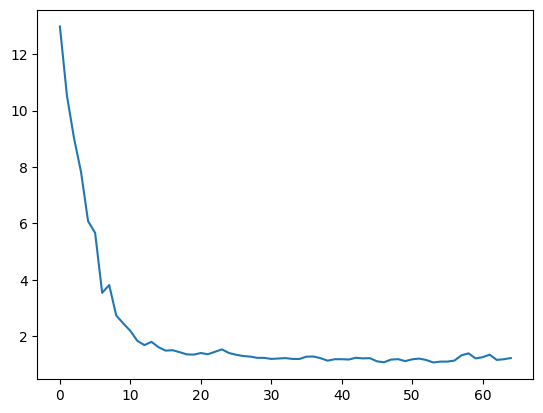

In [21]:
# Plotting graph for MLPClassifier

loss_values = model.loss_curve_
plt.plot(loss_values)
plt.show()

In [22]:
model1=MLPClassifier(alpha=0.001, batch_size=128, hidden_layer_sizes=(200, 200, 100, 50), learning_rate='adaptive', max_iter=500)

#Training the model
model1.fit(x_train,y_train)

model1.score(x_train, y_train)

0.5505050505050505

In [23]:
#Predict for the test set
y_pred1=model1.predict(x_test)

#Calculate the accuracy of our model
accuracy1=accuracy_score(y_true=y_test, y_pred=y_pred1)

#Print the accuracy
print("Accuracy: {:.2f}%".format(accuracy1*100))

Accuracy: 46.97%


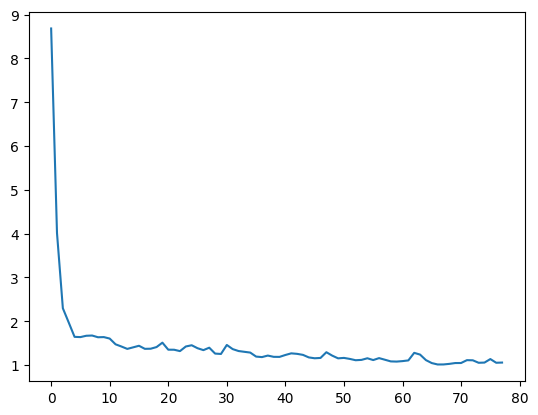

In [24]:
# Plotting graph for MLPClassifier

loss_values1 = model1.loss_curve_
plt.plot(loss_values1)
plt.show()

In [28]:
import os, pickle

out_dir = r'd:/project_learning/Nlp-2/Emotion_Recognition/models'
os.makedirs(out_dir, exist_ok=True)

model_path = os.path.join(out_dir, 'emotion_classification_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model1, f)

print(f'✅ Model saved to: {model_path}')


✅ Model saved to: d:/project_learning/Nlp-2/Emotion_Recognition/models\emotion_classification_model.pkl
